In [ ]:
import sys, subprocess
try:
    import matplotlib, seaborn, pandas as pd  # quick check
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "seaborn", "pandas"])
    import matplotlib, seaborn, pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

data_path = Path("../data/raw/data_de_aus_ch.csv")
df_snow = pd.read_csv(data_path)

# Nettoyage / formatage
# standardiser noms de colonnes (trim)
df_snow.columns = [c.strip() for c in df_snow.columns]

# convertir colonnes numériques
num_cols = ["Elevation (m)","Temperature (°C)","Precipitation (mm)","Daily Snow Depth (cm)",
            "Monthly Snow Depth (cm)","Mean Snow Depth (cm)","Max Snow Depth (cm)"]
for c in num_cols:
    if c in df_snow.columns:
        df_snow[c] = pd.to_numeric(df_snow[c], errors="coerce")

# créer colonne date (1er du mois)
df_snow["Year"] = pd.to_numeric(df_snow["Year"], errors="coerce").astype("Int64")
df_snow["Month"] = pd.to_numeric(df_snow["Month"], errors="coerce").astype("Int64")
df_snow = df_snow.dropna(subset=["Year","Month"])
df_snow["date"] = pd.to_datetime(dict(year=df_snow["Year"].astype(int),
                                      month=df_snow["Month"].astype(int),
                                      day=1))

# index utile
df_snow = df_snow.sort_values(["Region","date"]).reset_index(drop=True)

def plot_station_timeseries(station, col="Monthly Snow Depth (cm)", agg="mean", figsize=(12,4)):
    df = df_snow[df_snow["Region"] == station].copy()
    if df.empty:
        print(f"Station introuvable: {station}")
        return
    series = df.groupby("date")[col].agg(agg).sort_index()
    plt.figure(figsize=figsize)
    plt.plot(series.index, series.values, marker="o", linestyle="-")
    plt.title(f"{station} — {col} ({agg})")
    plt.ylabel(col)
    plt.xlabel("Date")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_station_seasonal_heatmap(station, col="Monthly Snow Depth (cm)", figsize=(10,6), cmap="YlGnBu"):
    df = df_snow[df_snow["Region"] == station].copy()
    if df.empty:
        print(f"Station introuvable: {station}")
        return
    pivot = df.pivot_table(index="Year", columns="Month", values=col, aggfunc="mean")
    plt.figure(figsize=figsize)
    sns.heatmap(pivot, cmap=cmap, cbar_kws={"label": col})
    plt.title(f"{station} — Heatmap saisonnière ({col})")
    plt.ylabel("Year")
    plt.xlabel("Month")
    plt.tight_layout()
    plt.show()

def plot_country_timeseries(country="Switzerland", col="Monthly Snow Depth (cm)", agg="mean", rolling=12, figsize=(12,4)):
    df = df_snow[df_snow["Country"].str.contains(country, na=False)].copy()
    if df.empty:
        print(f"Aucun enregistrement pour le pays: {country}")
        return
    ts = df.groupby("date")[col].agg(agg).sort_index()
    plt.figure(figsize=figsize)
    plt.plot(ts.index, ts.values, label=f"{agg} {col}", color="tab:blue")
    if rolling:
        plt.plot(ts.index, ts.rolling(window=rolling, min_periods=1).mean(), label=f"{rolling}-mois rolling", color="tab:red")
    plt.title(f"{country} — Évolution temporelle de {col}")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_top_stations_compare(stations, col="Monthly Snow Depth (cm)", figsize=(12,5)):
    plt.figure(figsize=figsize)
    for s in stations:
        df = df_snow[df_snow["Region"]==s].groupby("date")[col].mean().sort_index()
        if df.empty:
            continue
        plt.plot(df.index, df.values, label=s)
    plt.title(f"Comparaison stations — {col}")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_stations_yearly(stations, figsize=(10,4)):
    if isinstance(stations, str):
        stations = [stations]
    plt.figure(figsize=figsize)
    for s in stations:
        ser = df_yearly.loc[df_yearly["Region"]==s].set_index("Year")["Mean Snow Depth (cm)"].sort_index()
        if ser.empty:
            print(f"Avertissement — aucune donnée pour la station: {s}")
            continue
        plt.plot(ser.index, ser.values, marker="o", label=s)
    plt.xlabel("Year")
    plt.ylabel("Mean Snow Depth (cm)")
    plt.title("Évolution annuelle — Mean Snow Depth (cm)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_country_heatmap(country, figsize=(8,6), cmap="YlGnBu"):
    df_ct = df_snow[df_snow["Country"].str.contains(country, na=False)].dropna(subset=["Mean Snow Depth (cm)"])
    if df_ct.empty:
        print(f"Aucun enregistrement pour le pays: {country}")
        return
    df_yearly_st = (df_ct.groupby(["Region","Year"], as_index=False)["Mean Snow Depth (cm)"].mean())
    pivot_st = df_yearly_st.pivot(index="Region", columns="Year", values="Mean Snow Depth (cm)")
    plt.figure(figsize=figsize)
    sns.heatmap(pivot_st.fillna(0), cmap=cmap, cbar_kws={"label":"Mean Snow Depth (cm)"})
    plt.title(f"{country} — Mean Snow Depth (cm) par station / année")
    plt.ylabel("Region")
    plt.xlabel("Year")
    plt.tight_layout()
    plt.show()

def count_rows_where_column_less_than(df_or_name, column, threshold, inclusive=False, df_dict=None, data_dir=Path("../data/raw"), return_total=False):
    """
    Retourne le nombre de lignes où `column` est < threshold (ou <= si inclusive=True).

    - df_or_name : DataFrame ou nom de fichier (ex: 'ski-resorts.csv').
    - column : nom de la colonne.
    - threshold : valeur seuil (numérique).
    - inclusive : True pour <=, False pour <.
    - df_dict : dict contenant les DataFrame (par ex. variable `dataframes`), facultatif.
    - data_dir : répertoire où chercher le fichier si une string est fournie.
    - return_total : si True, retourne un dict avec le nombre de lignes correspondant et le total (rows et non-nulls).
    """
    # récupérer df_dict par défaut
    if df_dict is None:
        df_dict = globals().get("dataframes", {})

    # obtenir le DataFrame
    if isinstance(df_or_name, str):
        # 1) essayer dans df_dict
        df = df_dict.get(df_or_name)
        # 2) sinon essayer chemin relatif / dossier data_dir
        if df is None:
            p = Path(df_or_name)
            if not p.exists():
                p = data_dir / df_or_name
            if p.exists():
                df = pd.read_csv(p)
            else:
                raise ValueError(f"DataFrame/CSV '{df_or_name}' introuvable (ni dans df_dict ni à {p}).")
    else:
        df = df_or_name

    if column not in df.columns:
        raise ValueError(f"Colonne '{column}' non trouvée dans le DataFrame. Colonnes disponibles: {list(df.columns)[:10]}...")

    series = pd.to_numeric(df[column], errors="coerce")
    mask = series.le(threshold) if inclusive else series.lt(threshold)
    count = int(mask.sum())
    total_rows = int(len(df))
    total_non_null = int(series.notna().sum())

    if return_total:
        return {"count": count, "total_rows": total_rows, "total_non_null": total_non_null}
    return count

In [9]:
count_rows_where_column_less_than("ski-resorts.csv", "elevation_top_m", 1200, return_total=True)
# count_rows_where_column_less_than(df_snow, "Mean Snow Depth (cm)", 10, inclusive=True)

{'count': 1864, 'total_rows': 3284, 'total_non_null': 3284}

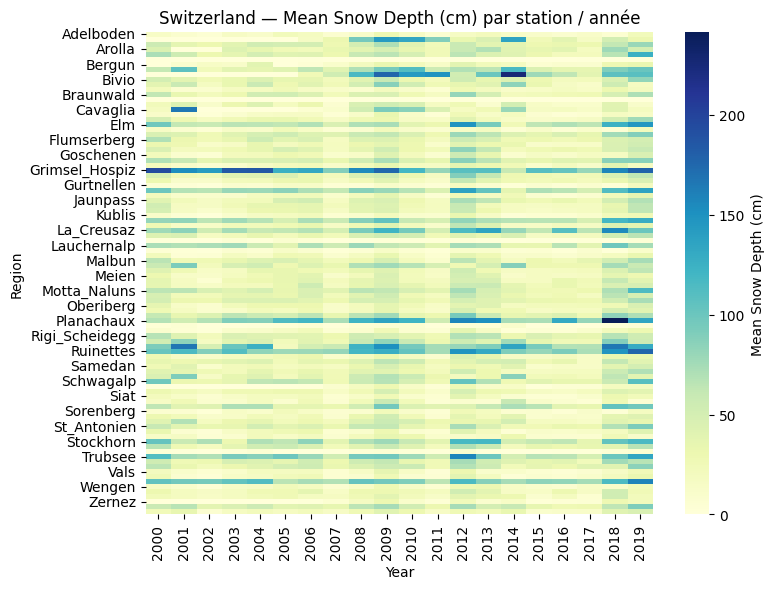

In [11]:
plot_country_heatmap("Switzerland")


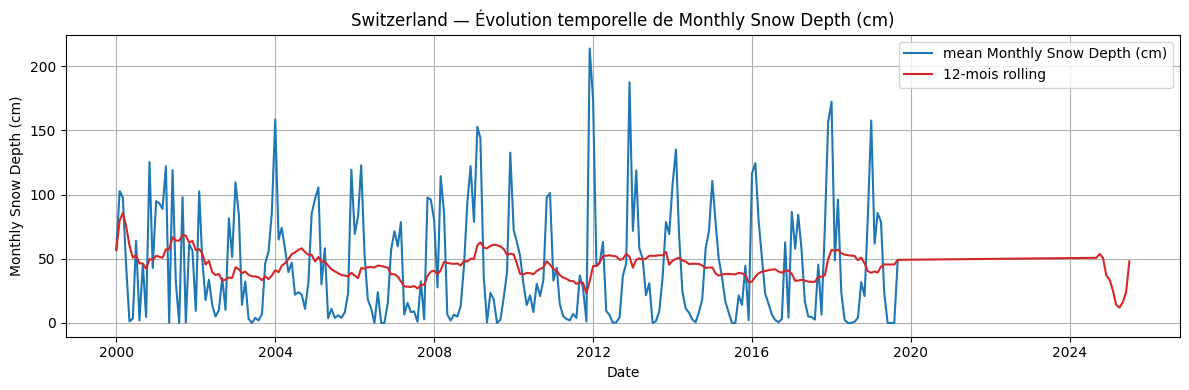

In [12]:
plot_country_timeseries("Switzerland")

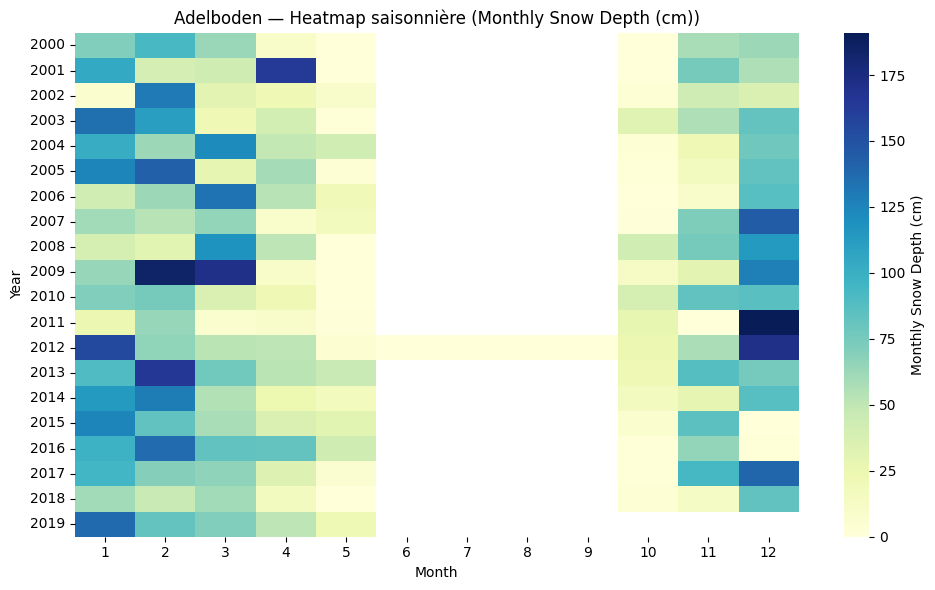

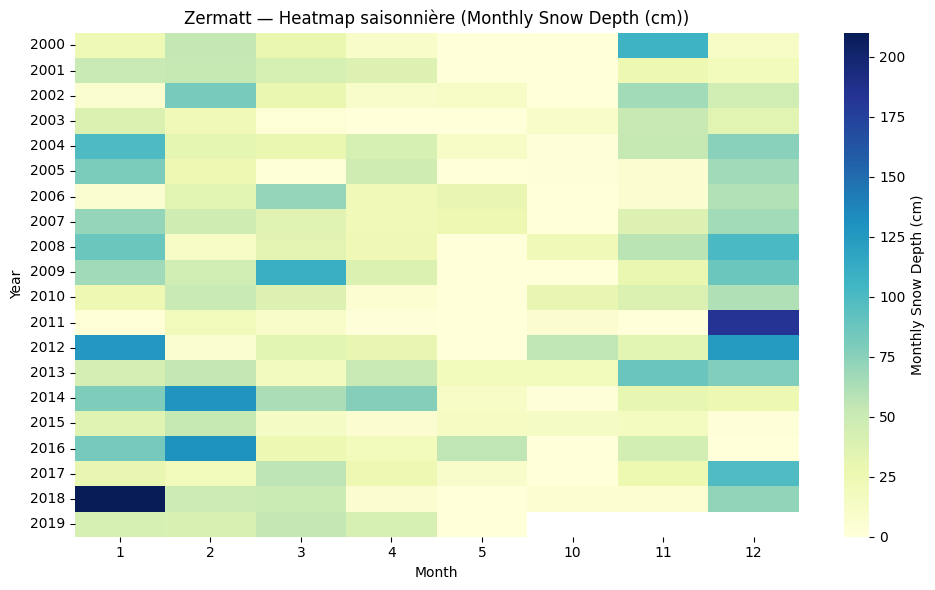

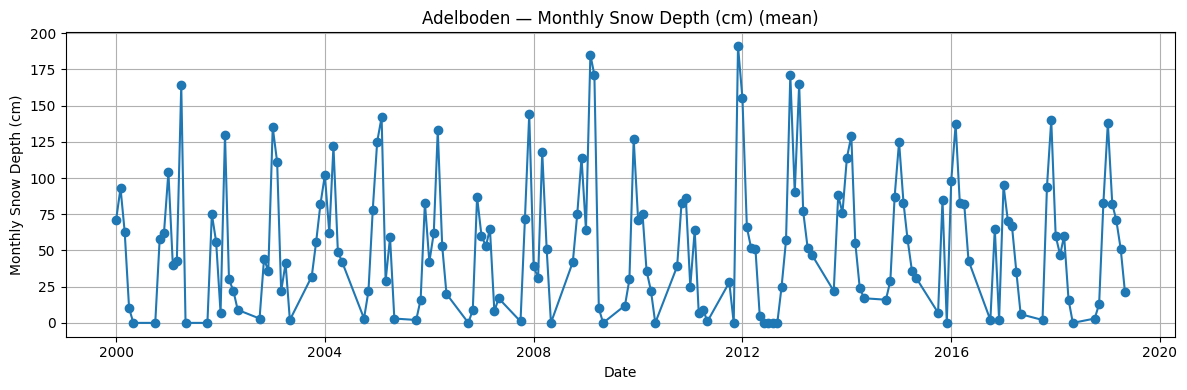

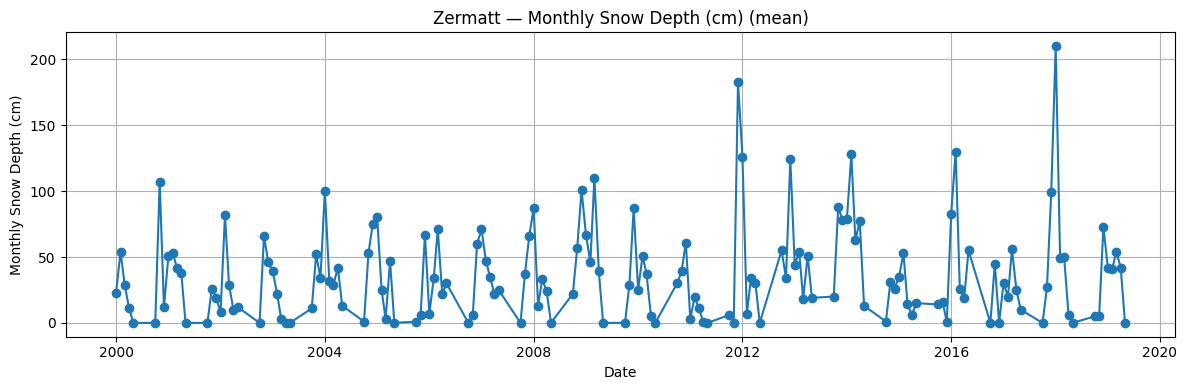

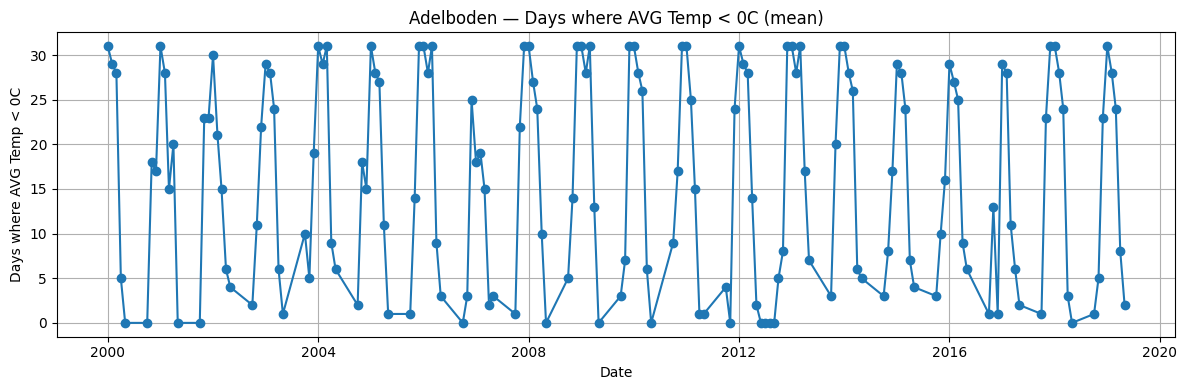

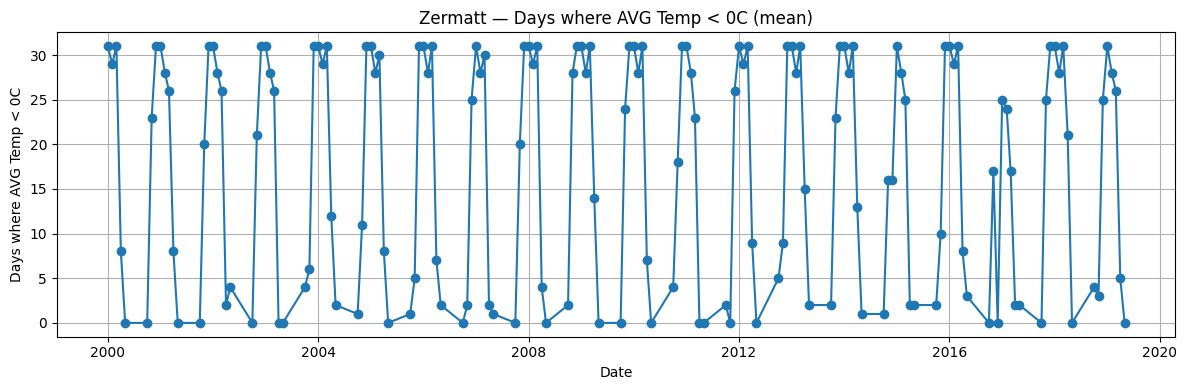

In [16]:
plot_station_seasonal_heatmap("Adelboden")
plot_station_seasonal_heatmap("Zermatt")
plot_station_timeseries("Adelboden")
plot_station_timeseries("Zermatt")
plot_station_timeseries("Adelboden", col="Days where AVG Temp < 0C")
plot_station_timeseries("Zermatt", col="Days where AVG Temp < 0C")

/var/folders/11/f72wbpk55n5_c8y3shf_d8600000gn/T/ipykernel_53699/1819409685.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette=["#2b8cbe", "#f03b20"])


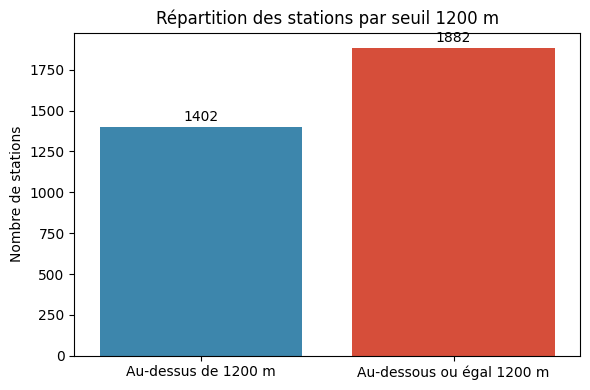

In [7]:
# ...existing code...
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

path = Path("../data/raw/ski-resorts.csv")
# lecture robuste
for enc in ("utf-8","latin-1","cp1252"):
    try:
        df = pd.read_csv(path, encoding=enc)
        break
    except Exception:
        df = None
if df is None:
    df = pd.read_csv(path, engine="python", encoding_errors="replace")

df.columns = [c.strip() for c in df.columns]
elev_col = next((c for c in df.columns if "elev" in c.lower()), None)
if elev_col is None:
    raise ValueError("Colonne d'élévation introuvable dans ski-resorts.csv")

df[elev_col] = pd.to_numeric(df[elev_col], errors="coerce")

# compter (ignorer NaN)
above_count = int((df[elev_col] > 1200).sum())
below_count = int((df[elev_col] <= 1200).sum())

labels = ["Au-dessus de 1200 m", "Au-dessous ou égal 1200 m"]
counts = [above_count, below_count]

plt.figure(figsize=(6,4))
sns.barplot(x=labels, y=counts, palette=["#2b8cbe", "#f03b20"])
for i, v in enumerate(counts):
    plt.text(i, v + max(1, max(counts)*0.02), str(v), ha="center")
plt.ylabel("Nombre de stations")
plt.title("Répartition des stations par seuil 1200 m")
plt.tight_layout()
plt.show()
# ...existing code...